In [7]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

In [ ]:
MODELS   = ["olmoe", "deepseek-v2-lite", "mixtral-8x7b", "mixtral-8x22b", "qwen3-30b-a3b", "phi-3.5-moe"]
DATASETS = ["c4", "math", "code"]

dags: dict[tuple[str, str], dict] = {}
for m in MODELS:
    for d in DATASETS:
        path = os.path.join(config["result_path"], f"circuits/dag_{m}_{d}.pt")
        dags[(m, d)] = torch.load(path, map_location="cpu")

In [10]:
from experiments.circuits.helper import get_thresholds, thresholding_routing_graph, show_enhanced_layered_graph

TARGET, Q = "AARV", 0.99
for m in MODELS:
    for d in DATASETS: 
        dag = dags[(m, d)]
        t = get_thresholds(dag, TARGET, [Q])[Q]
        g = thresholding_routing_graph(dag, TARGET, t)
        # show_enhanced_layered_graph(g, quantile=Q, target=TARGET, model=m, dataset=d, n_prompts=dag["n_prompts"])

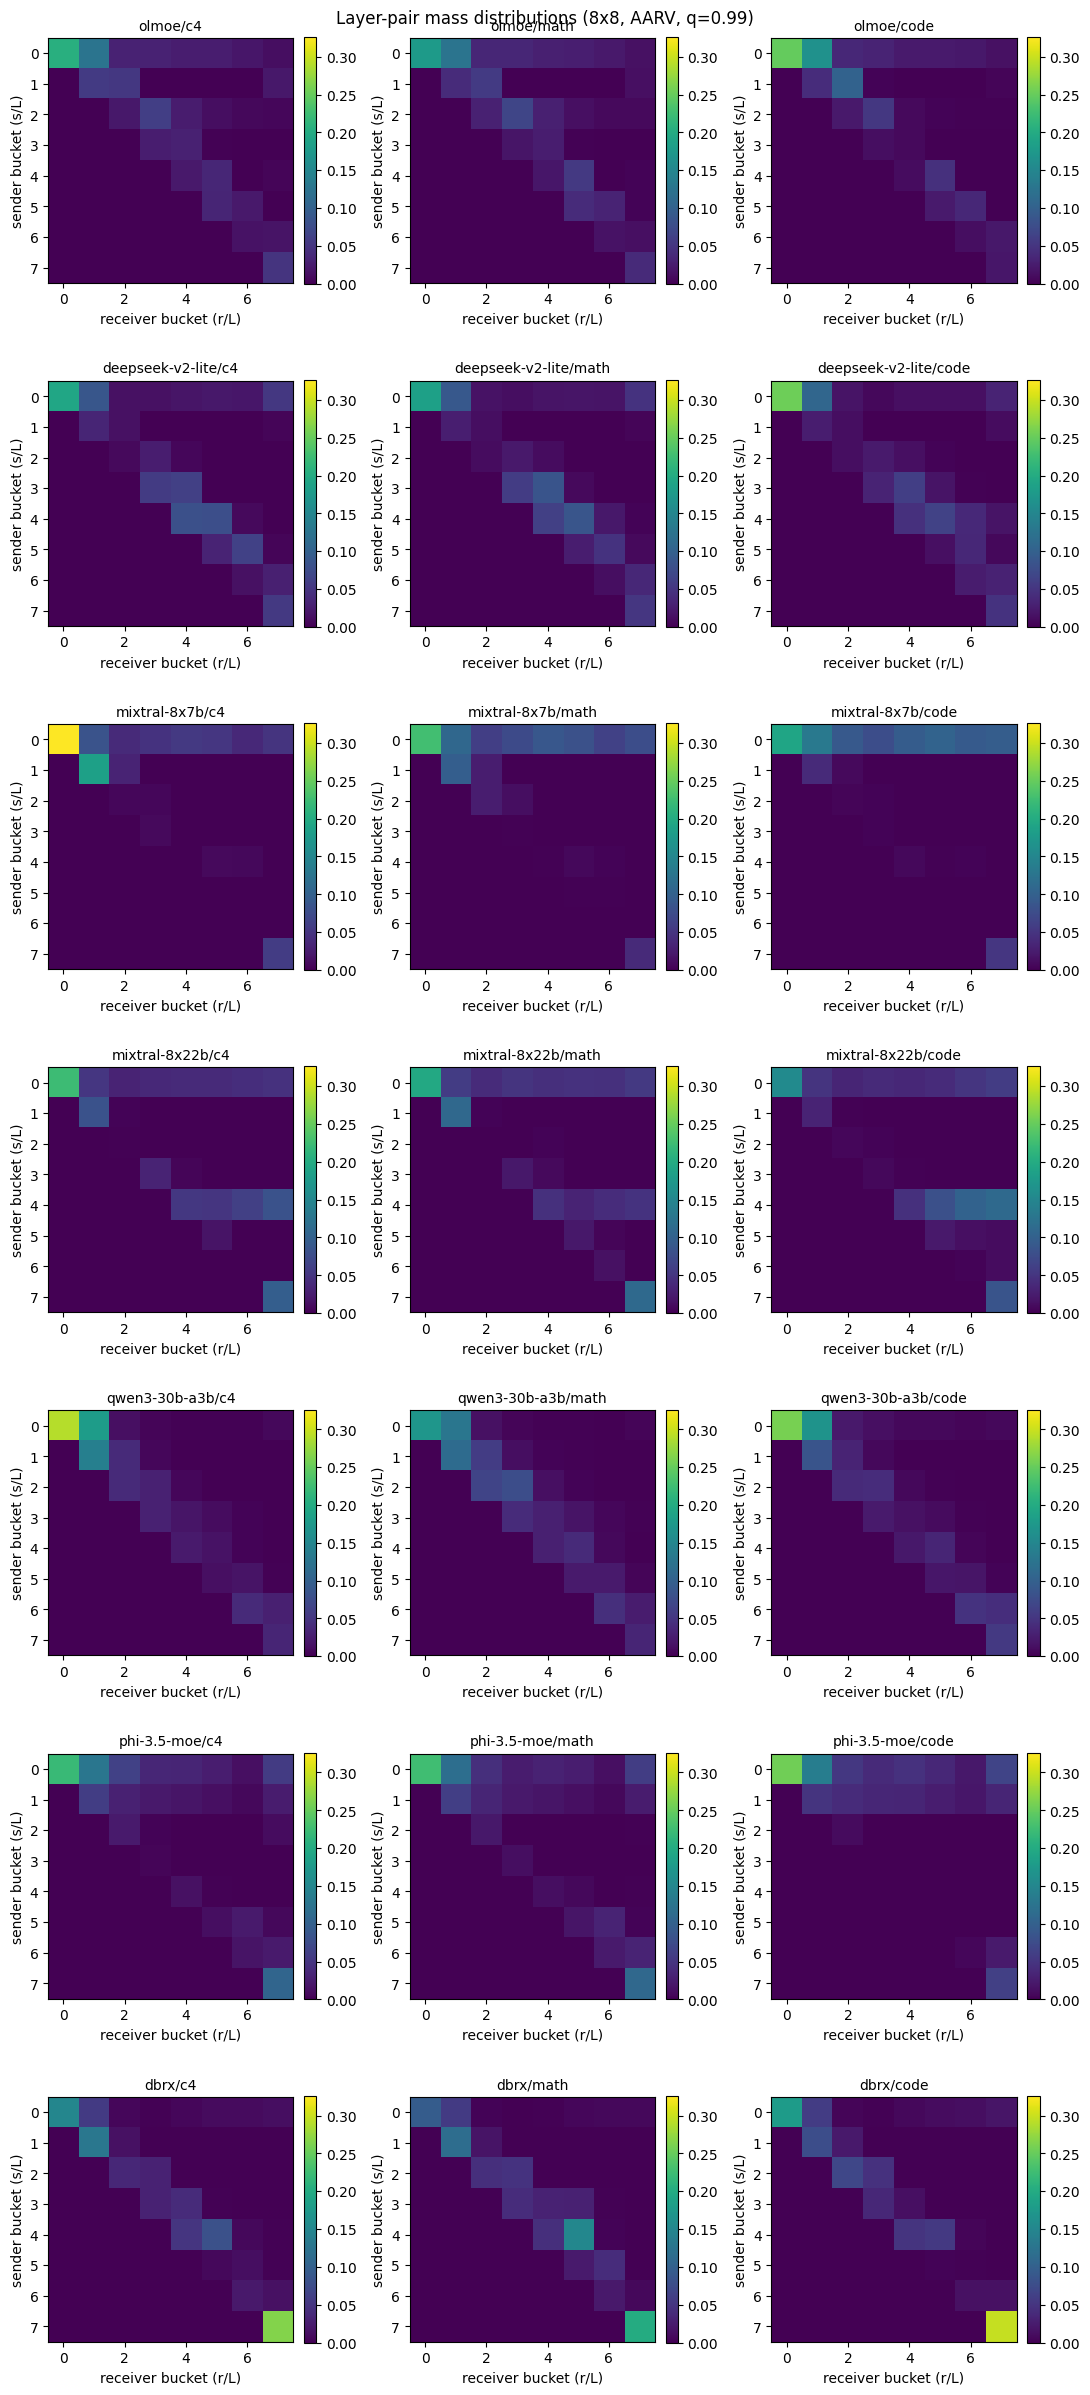

In [11]:
# --- Layer-pair mass (LPM) fingerprint: "where do edges live?" ---
# Sparsify each DAG (same threshold as the viz), bucket edges by relative
# depth (s/L, r/L) into an N_BUCKETS x N_BUCKETS grid, normalize to a
# probability distribution. Size-invariant by construction.
from experiments.circuits.helper import get_thresholds, layer_pair_mass, lpm_similarity

WEIGHT, Q, N_BUCKETS = "AARV", 0.99, 8

M_dict = {}
for key, dag in dags.items():
    W = dag[WEIGHT]
    if isinstance(W, torch.Tensor):
        W = W.cpu().numpy().astype(np.float64)
    t = get_thresholds(dag, WEIGHT, [Q])[Q]
    Ws = np.where(np.abs(W) >= t, W, 0.0)
    M_dict[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)

# Grid: rows = models, cols = datasets.
fig, axes = plt.subplots(len(MODELS), len(DATASETS), figsize=(11, 3.5 * len(MODELS)))
vmax = max(M.max() for M in M_dict.values())
for i, m in enumerate(MODELS):
    for j, d in enumerate(DATASETS):
        ax = axes[i, j] if len(MODELS) > 1 else axes[j]
        im = ax.imshow(M_dict[(m, d)], cmap="viridis", origin="upper", vmin=0, vmax=vmax)
        ax.set_title(f"{m}/{d}", fontsize=10)
        ax.set_xlabel("receiver bucket (r/L)")
        ax.set_ylabel("sender bucket (s/L)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Layer-pair mass distributions ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})")
plt.tight_layout(); plt.show()

In [ ]:
# --- 18x18 LPM similarity matrix + pairwise cross-model aggregates ---
# Restricted to softmax+L1-normalized routing architectures (consistent application
# of the score decomposition framework). DBRX and Llama 4 deferred.
keys = list(dags.keys())
n = len(keys)
LPM_COS = np.zeros((n, n))
LPM_TV  = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        LPM_COS[i, j] = lpm_similarity(M_dict[keys[i]], M_dict[keys[j]], metric="cosine")
        LPM_TV[i, j]  = lpm_similarity(M_dict[keys[i]], M_dict[keys[j]], metric="tv")

short = {
    "olmoe":            "olmo",
    "deepseek-v2-lite": "deep",
    "mixtral-8x7b":     "mx7b",
    "mixtral-8x22b":    "mx22",
    "qwen3-30b-a3b":    "qwn3",
    "phi-3.5-moe":      "phi3",
    "qwen3-235b-a22b":  "q235",
}
labels = [f"{short.get(k[0], k[0][:4])}/{k[1]}" for k in keys]

fig, axes = plt.subplots(1, 2, figsize=(19, 8.5))
for ax, (M, title) in zip(axes, [
    (LPM_COS, f"LPM cosine ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})"),
    (LPM_TV,  f"LPM TV-sim ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})"),
]):
    off_diag = M[~np.eye(n, dtype=bool)]
    vmin = float(off_diag.min())
    im = ax.imshow(M, cmap="viridis", vmin=vmin, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    mid = (vmin + 1.0) / 2
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    color="white" if M[i, j] < mid else "black", fontsize=5)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
plt.tight_layout(); plt.show()


# Block aggregates: within-model (task stability) + pairwise cross-model.
def block_mean(M, rows, cols, exclude_diag=False):
    vals = [M[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
    return float(np.mean(vals)) if vals else float("nan")

model_idx = {m: [i for i, k in enumerate(keys) if k[0] == m] for m in MODELS}

for name, M in [("LPM cosine", LPM_COS), ("LPM TV-sim", LPM_TV)]:
    print(f"--- {name}  (K={N_BUCKETS}, sparsified {WEIGHT}, q={Q}) ---")
    print("  Within-model (task stability):")
    for m in MODELS:
        wm = block_mean(M, model_idx[m], model_idx[m], exclude_diag=True)
        print(f"    WM[{m:<18s}] = {wm:.3f}")
    print("  Cross-model (CMS = same-dataset, CMD = different-dataset):")
    pairs = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
    for m_a, m_b in pairs:
        idx_a, idx_b = model_idx[m_a], model_idx[m_b]
        CMS = float(np.mean([M[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]]))
        CMD = float(np.mean([M[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]]))
        print(f"    {m_a:<18s} <-> {m_b:<18s}  CMS={CMS:.3f}  CMD={CMD:.3f}")
    print()

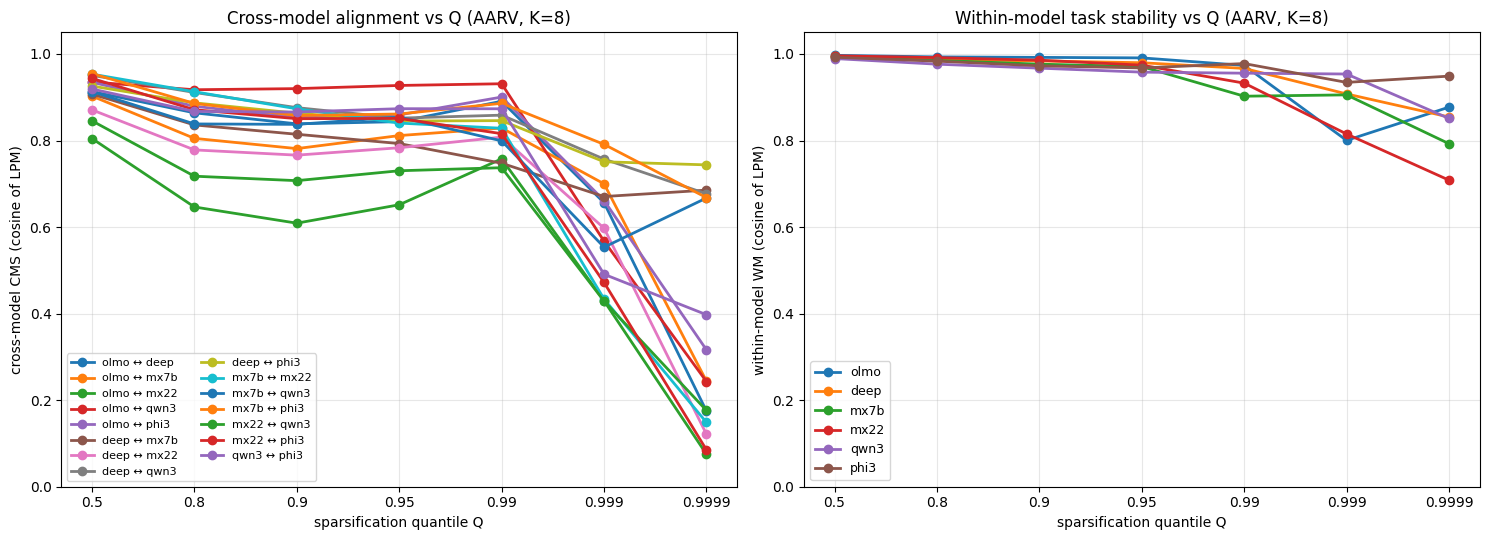

Q values:      0.5     0.8     0.9    0.95    0.99   0.999  0.9999

Cross-model CMS:
  olmo ↔ deep      0.913   0.864   0.839   0.844   0.891   0.656   0.175
  olmo ↔ mx7b      0.903   0.805   0.781   0.811   0.829   0.700   0.244
  olmo ↔ mx22      0.805   0.646   0.609   0.652   0.758   0.430   0.075
  olmo ↔ qwn3      0.935   0.917   0.920   0.927   0.931   0.567   0.243
  olmo ↔ phi3      0.935   0.879   0.853   0.859   0.900   0.661   0.316
  deep ↔ mx7b      0.907   0.836   0.814   0.793   0.747   0.671   0.685
  deep ↔ mx22      0.871   0.778   0.766   0.783   0.808   0.597   0.121
  deep ↔ qwn3      0.951   0.911   0.876   0.852   0.859   0.757   0.677
  deep ↔ phi3      0.926   0.887   0.863   0.845   0.846   0.751   0.744
  mx7b ↔ mx22      0.953   0.913   0.873   0.840   0.828   0.434   0.149
  mx7b ↔ qwn3      0.913   0.838   0.837   0.854   0.799   0.554   0.667
  mx7b ↔ phi3      0.955   0.886   0.858   0.861   0.886   0.791   0.668
  mx22 ↔ qwn3      0.845   0.718   0.70

In [6]:
# --- Sparsification sweep: how do cross-model alignment + task stability vary with Q? ---
# Diagnostic for metric robustness. If pair rankings reorder dramatically as Q varies,
# the LPM metric is unreliable as a similarity measure. If curves are roughly parallel
# across a wide Q range, that's the stable regime we should report.
Q_VALUES = [0.5, 0.8, 0.9, 0.95, 0.99, 0.999, 0.9999]

pair_keys = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
CMS_curves = {p: [] for p in pair_keys}
CMD_curves = {p: [] for p in pair_keys}
WM_curves  = {m: [] for m in MODELS}

for Q_s in Q_VALUES:
    M_dict_s = {}
    for key, dag in dags.items():
        W = dag[WEIGHT]
        if isinstance(W, torch.Tensor):
            W = W.cpu().numpy().astype(np.float64)
        t = get_thresholds(dag, WEIGHT, [Q_s])[Q_s]
        Ws = np.where(np.abs(W) >= t, W, 0.0)
        M_dict_s[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)
    SIM_s = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            SIM_s[i, j] = lpm_similarity(M_dict_s[keys[i]], M_dict_s[keys[j]], metric="cosine")
    for m in MODELS:
        WM_curves[m].append(block_mean(SIM_s, model_idx[m], model_idx[m], exclude_diag=True))
    for (m_a, m_b) in pair_keys:
        idx_a, idx_b = model_idx[m_a], model_idx[m_b]
        CMS_curves[(m_a, m_b)].append(
            float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]])))
        CMD_curves[(m_a, m_b)].append(
            float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]])))

# Plot 1: cross-model CMS as a function of Q (6 pairs).
# Plot 2: within-model WM as a function of Q (4 models).
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x = np.arange(len(Q_VALUES))

short_pair = lambda p: f"{short[p[0]]} ↔ {short[p[1]]}"
ax = axes[0]
for p in pair_keys:
    ax.plot(x, CMS_curves[p], marker="o", linewidth=2, label=short_pair(p))
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
ax.set_xlabel("sparsification quantile Q")
ax.set_ylabel("cross-model CMS (cosine of LPM)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncol=2, loc="lower left")
ax.grid(alpha=0.3)
ax.set_title(f"Cross-model alignment vs Q ({WEIGHT}, K={N_BUCKETS})")

ax = axes[1]
for m in MODELS:
    ax.plot(x, WM_curves[m], marker="o", linewidth=2, label=short[m])
ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
ax.set_xlabel("sparsification quantile Q")
ax.set_ylabel("within-model WM (cosine of LPM)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_title(f"Within-model task stability vs Q ({WEIGHT}, K={N_BUCKETS})")

plt.tight_layout(); plt.show()

# Numeric output.
print(f"Q values:  {' '.join(f'{q:>7g}' for q in Q_VALUES)}")
print(f"\nCross-model CMS:")
for p in pair_keys:
    vals = " ".join(f"{v:>7.3f}" for v in CMS_curves[p])
    print(f"  {short_pair(p):<14s} {vals}")
print(f"\nCross-model CMS − CMD  (Platonic per-task signal; ~0 means no per-task alignment):")
for p in pair_keys:
    diffs = [c - d for c, d in zip(CMS_curves[p], CMD_curves[p])]
    vals = " ".join(f"{v:>+7.3f}" for v in diffs)
    print(f"  {short_pair(p):<14s} {vals}")
print(f"\nWithin-model WM:")
for m in MODELS:
    vals = " ".join(f"{v:>7.3f}" for v in WM_curves[m])
    print(f"  {short[m]:<6s}        {vals}")

In [ ]:
# --- Correctness tests across all DAGs ---
# Catches: NaN/Inf, sign-constraint violations, backward-edge contamination,
# shape inconsistencies, routing imbalance, suspicious magnitudes, and broken
# LPM fingerprint normalization. Plus a DBRX-specific bucket-concentration
# diagnostic to see *why* DBRX is an outlier.

print("=" * 80)
print(f"DAG correctness checks  ({len(dags)} DAGs)")
print("=" * 80)
print()

n_pass = 0
soft_warnings = []

for key in dags:
    m, d = key
    dag = dags[key]
    issues = []
    L, E = dag["APS"].shape[0], dag["APS"].shape[1]
    expected_shape = (L, E, L, E)

    # 1. Shape consistency across the 5 weight tensors
    for w in ["APS", "ANS", "AVG", "VAR", "AARV"]:
        if tuple(dag[w].shape) != expected_shape:
            issues.append(f"shape mismatch: {w} is {tuple(dag[w].shape)} vs {expected_shape}")

    # 2. NaN / Inf
    for w in ["APS", "ANS", "AVG", "VAR", "AARV"]:
        t = dag[w].float()
        n_nan, n_inf = int(torch.isnan(t).sum()), int(torch.isinf(t).sum())
        if n_nan:
            issues.append(f"{w}: {n_nan} NaN")
        if n_inf:
            issues.append(f"{w}: {n_inf} Inf")

    # 3. Sign constraints from the score-decomposition definitions
    n_aps_neg  = int((dag["APS"]  < 0).sum())
    n_ans_pos  = int((dag["ANS"]  > 0).sum())
    n_var_neg  = int((dag["VAR"]  < 0).sum())
    n_aarv_neg = int((dag["AARV"] < 0).sum())
    if n_aps_neg:  issues.append(f"APS has {n_aps_neg} negative entries (expected APS >= 0)")
    if n_ans_pos:  issues.append(f"ANS has {n_ans_pos} positive entries (expected ANS <= 0)")
    if n_var_neg:  issues.append(f"VAR has {n_var_neg} negative entries (expected VAR >= 0)")
    if n_aarv_neg: issues.append(f"AARV has {n_aarv_neg} negative entries (expected abs(.) >= 0)")

    # 4. Forward-edge mask: s >= r should be exactly 0
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    backward = (s_idx >= r_idx).expand_as(dag["APS"])
    for w in ["APS", "ANS", "AVG", "VAR", "AARV"]:
        n_bwd = int((dag[w][backward] != 0).sum())
        if n_bwd:
            issues.append(f"{w}: {n_bwd} nonzero entries with sender >= receiver")

    # 5. Magnitude sanity
    aps_max = float(dag["APS"].abs().max())
    if aps_max > 1e6:
        issues.append(f"APS abs max = {aps_max:.2e} is suspiciously large")

    # 6. Routing balance (soft warning, not a fail)
    count = dag["count"]
    n_zero_count = int((count == 0).sum())
    if n_zero_count > 0:
        soft_warnings.append(f"{m}/{d}: {n_zero_count}/{L*E} (layer, expert) cells never fired")

    nnz_aps = int((dag["APS"] != 0).sum())
    status = "PASS" if not issues else "FAIL"
    if not issues:
        n_pass += 1
    print(f"  {status:<4s}  {m:<18s} {d:<5s}  L={L:>3d}  E={E:>4d}  nnz_APS={nnz_aps:>8d}  APS_max={aps_max:8.3g}")
    for issue in issues:
        print(f"        ! {issue}")

print()
print(f"Hard-check summary: {n_pass}/{len(dags)} DAGs pass.")
if soft_warnings:
    print()
    print(f"Soft warnings ({len(soft_warnings)} — non-fatal, but worth noting):")
    for w in soft_warnings:
        print(f"  - {w}")

# --- LPM fingerprint normalization ---
print()
print("=" * 80)
print("LPM fingerprint normalization  (each fingerprint should sum to 1.0)")
print("=" * 80)
n_fp_pass = 0
for key in M_dict:
    M = M_dict[key]
    total, mx, n_nz = float(M.sum()), float(M.max()), int((M > 0).sum())
    ok = abs(total - 1.0) < 1e-6
    n_fp_pass += int(ok)
    marker = "  " if ok else "! "
    print(f"  {marker}{key[0]:<18s} {key[1]:<5s}  sum={total:.6f}  max={mx:.4f}  nonzero={n_nz:>3d}/{N_BUCKETS*N_BUCKETS}")
print()
print(f"Fingerprint normalization: {n_fp_pass}/{len(M_dict)} fingerprints normalized correctly.")

# --- DBRX-specific bucket-concentration diagnostic ---
print()
print("=" * 80)
print("DBRX bucket concentration diagnostic")
print("=" * 80)
if "dbrx" in MODELS:
    non_dbrx_fps = [M_dict[k] for k in M_dict if k[0] != "dbrx"]
    cluster_mean = np.mean(non_dbrx_fps, axis=0)
    dbrx_mean    = np.mean([M_dict[("dbrx", d)] for d in DATASETS], axis=0)

    def top3_buckets(flat, label):
        top = np.argsort(flat)[-3:][::-1]
        for idx in top:
            s, r = idx // N_BUCKETS, idx % N_BUCKETS
            print(f"    {label}  (s/L={s/N_BUCKETS:.2f}, r/L={r/N_BUCKETS:.2f}): {flat[idx]:.4f}")

    print("  Top-3 buckets in NON-DBRX cluster average:")
    top3_buckets(cluster_mean.flatten(), "cluster")
    print("  Top-3 buckets in DBRX (averaged over c4/math/code):")
    top3_buckets(dbrx_mean.flatten(), "dbrx   ")

    # Largest divergences between DBRX and the cluster
    diff = dbrx_mean - cluster_mean
    flat_diff = diff.flatten()
    abs_idx = np.argsort(np.abs(flat_diff))[-5:][::-1]
    print("  Top-5 |DBRX - cluster| bucket differences:")
    for idx in abs_idx:
        s, r = idx // N_BUCKETS, idx % N_BUCKETS
        sign = "+" if flat_diff[idx] > 0 else "-"
        print(f"    (s/L={s/N_BUCKETS:.2f}, r/L={r/N_BUCKETS:.2f}):  DBRX={dbrx_mean.flatten()[idx]:.4f}  cluster={cluster_mean.flatten()[idx]:.4f}  diff={sign}{abs(flat_diff[idx]):.4f}")
else:
    print("  (DBRX not in MODELS list — skipping.)")